In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Shape, dtypes, memory
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: (101766, 50)

Column types:
object    37
int64     13
Name: count, dtype: int64

Memory usage: 202.2 MB


In [6]:
# What does a patient record actually look like?
df.head(3).T  # Transposed — easier to read with 50 columns

,0,1,2
encounter_id,2278392,149190,64410
patient_nbr,8222157,55629189,86047875
race,Caucasian,Caucasian,AfricanAmerican
gender,Female,Female,Female
age,[0-10),[10-20),[20-30)
weight,?,?,?
admission_type_id,6,1,1
discharge_disposition_id,25,1,1
admission_source_id,1,7,7
time_in_hospital,1,3,2


In [10]:
# Our target: was patient readmitted within 30 days?
print(df['readmitted'].value_counts())
print(df['readmitted'].value_counts(normalize=True).round(3))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


In [8]:
# Replace the ? placeholders first
df.replace('?', np.nan, inplace=True)

# Now audit missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_report[missing_report['missing_count'] > 0])

                   missing_count  missing_pct
weight                     98569        96.86
max_glu_serum              96420        94.75
A1Cresult                  84748        83.28
medical_specialty          49949        49.08
payer_code                 40256        39.56
race                        2273         2.23
diag_3                      1423         1.40
diag_2                       358         0.35
diag_1                        21         0.02


## Missing Value Treatment Decisions

### Dropped Columns

- **weight (96.86% missing)**
  - Extremely sparse.
  - Retaining would introduce excessive uncertainty.
  - Dropped from analysis.

- **max_glu_serum (94.75% missing)**
  - Majority of records unavailable.
  - Not reliable for predictive modeling.
  - Dropped.

- **A1Cresult (83.28% missing)**
  - Missing values dominate the feature.
  - Dropped to avoid noise.

- **payer_code (39.56% missing)**
  - High missingness and limited clinical relevance.
  - Dropped.

### Retained Columns

- **medical_specialty (49.08% missing)**
  - Potentially useful clinical information.
  - Missing values will be replaced with "Unknown".

- **race (2.23% missing)**
  - Low missingness.
  - Imputed using mode.

- **diag_1, diag_2, diag_3**
  - Very low missingness.
  - Imputed using mode.

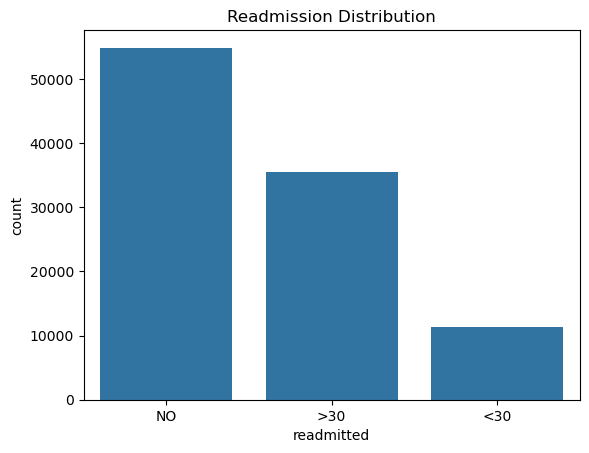

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='readmitted', data=df, order=df['readmitted'].value_counts().index)
plt.title('Readmission Distribution')
plt.savefig('../reports/readmission_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Numerical features
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

df[num_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


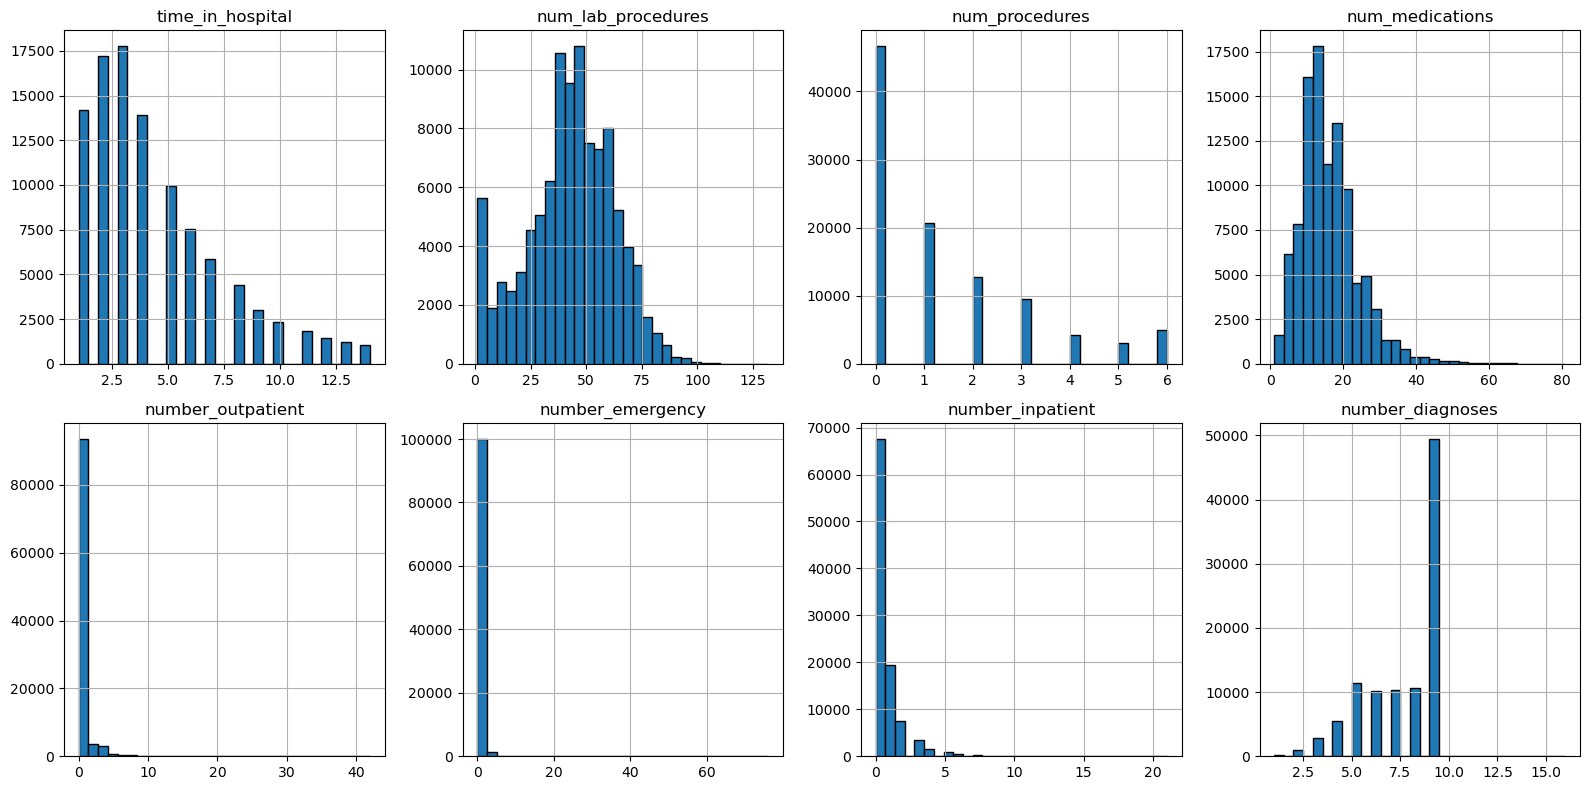

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(ax=ax, bins=30, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../reports/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Categorical features worth eyeballing
cat_cols = ['race', 'gender', 'age', 'admission_type_id',
            'discharge_disposition_id', 'admission_source_id']

for col in cat_cols:
    print(f"\n{col}:\n{df[col].value_counts().head(6)}")


race:
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

age:
age
[70-80)    26068
[60-70)    22483
[50-60)    17256
[80-90)    17197
[40-50)     9685
[30-40)     3775
Name: count, dtype: int64

admission_type_id:
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
Name: count, dtype: int64

discharge_disposition_id:
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
Name: count, dtype: int64

admission_source_id:
admission_source_id
7     57494
1     29565
17     6781
4      3187
6      2264
2      1104
Name: count, dtype: int64


In [20]:
# Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Multiple encounters per patient
encounter_counts = df['patient_nbr'].value_counts()
print(f"\nPatients with multiple encounters: {(encounter_counts > 1).sum()}")
print(f"Max encounters for one patient: {encounter_counts.max()}")
print(f"\nEncounter distribution:\n{encounter_counts.value_counts().head(10)}")

Duplicate rows: 0

Patients with multiple encounters: 16773
Max encounters for one patient: 40

Encounter distribution:
count
1     54745
2     10434
3      3328
4      1421
5       717
6       346
7       207
8       111
9        70
10       42
Name: count, dtype: int64


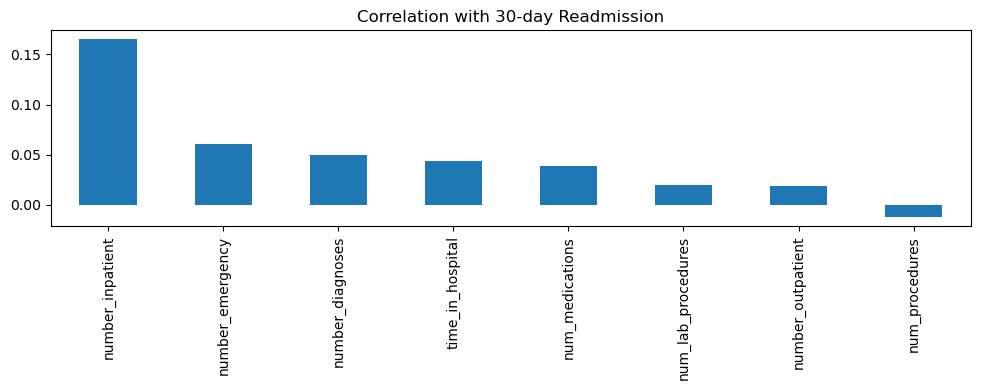

In [22]:
# Temporary binary target for correlation
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

corr = df[num_cols + ['readmitted_30']].corr()['readmitted_30'].drop('readmitted_30')
corr.sort_values(ascending=False).plot(kind='bar', figsize=(10, 4), title='Correlation with 30-day Readmission')
plt.tight_layout()
plt.savefig('../reports/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Target distribution
print("Readmission Distribution (%):")
print((df['readmitted'].value_counts(normalize=True) * 100).round(2))

print("\n")

# Patient statistics
total_encounters = len(df)
unique_patients = df['patient_nbr'].nunique()

print(f"Total encounters: {total_encounters:,}")
print(f"Unique patients: {unique_patients:,}")
print(f"Repeat encounters: {total_encounters - unique_patients:,}")
print(f"Repeat encounter rate: {(1 - unique_patients/total_encounters)*100:.2f}%")

Readmission Distribution (%):
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


Total encounters: 101,766
Unique patients: 71,518
Repeat encounters: 30,248
Repeat encounter rate: 29.72%
